# Project 1: Online / Incremental Stock Price Forecasting
## Deep Learning CA02 — B9AI104 | MSc AI

| | |
|---|---|
| **Model 1** | Vanilla LSTM — offline baseline |
| **Model 2** | Online LSTM — streaming incremental updates |
| **Model 3** | IL-ETransformer — Incremental Transformer + EWC |

**Evaluation Metrics:** RMSE · MAE · MSE · MAPE · Directional Accuracy (DA%)

---
> 🚀 **Instructions:** Runtime → Change runtime type → **T4 GPU**. Then: Runtime → Run all.
> Each cell can also be run individually top-to-bottom.

## Install Libraries

In [ ]:
!pip install yfinance --quiet
!pip install torch torchvision --quiet
import warnings; warnings.filterwarnings('ignore')
print('Libraries ready.')

Libraries ready.


## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math, copy
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Configuration

In [ ]:
TICKER        = 'AAPL'      # Change to any Yahoo Finance ticker (e.g. 'TSLA', 'BTC-USD')
START_DATE    = '2015-01-01'
END_DATE      = '2024-12-31'
LOOKBACK      = 60           # Sliding window size (trading days)
HIDDEN_SIZE   = 128
NUM_LAYERS    = 2
DROPOUT       = 0.2
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-3
TRAIN_SPLIT   = 0.70
VAL_SPLIT     = 0.15        # Test = remaining 15%
ONLINE_WINDOW = 20          # Steps between streaming weight updates
EWC_LAMBDA    = 400         # Elastic Weight Consolidation strength
print(f'Ticker={TICKER} | Lookback={LOOKBACK} | Epochs={EPOCHS}')

Ticker=AAPL | Lookback=60 | Epochs=50


## Download & Explore Data

2515 trading days downloaded for AAPL
Price             Open        High         Low       Close    Volume
Date                                                                
2024-12-23  253.385849  254.261058  252.073014  253.883133  40858800
2024-12-24  254.101927  256.807136  253.903002  256.797211  23234700
2024-12-26  256.787224  258.686851  256.230269  257.612701  27237100
2024-12-27  256.429191  257.294489  251.685117  254.201370  42355300
2024-12-30  250.859624  252.122728  249.387669  250.829788  35557500


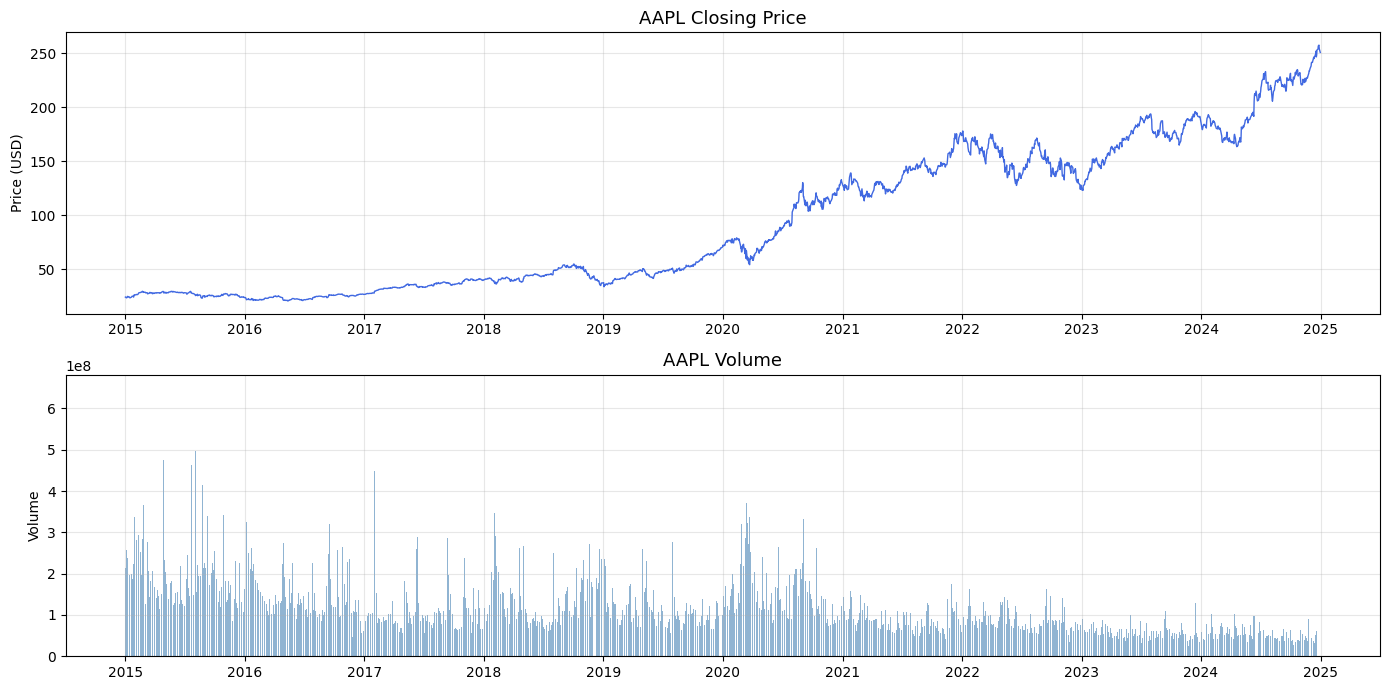

In [ ]:
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
raw.dropna(inplace=True)
raw.columns = raw.columns.droplevel(1) # Flatten MultiIndex columns
print(f'{len(raw)} trading days downloaded for {TICKER}')
print(raw[['Open','High','Low','Close','Volume']].tail(5))

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(raw.index, raw['Close'], color='royalblue', linewidth=1)
axes[0].set_title(f'{TICKER} Closing Price', fontsize=13)
axes[0].set_ylabel('Price (USD)'); axes[0].grid(alpha=0.3)
axes[1].bar(raw.index, raw['Volume'], color='steelblue', alpha=0.6, width=1)
axes[1].set_title(f'{TICKER} Volume', fontsize=13)
axes[1].set_ylabel('Volume'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('01_raw_data.png', dpi=150, bbox_inches='tight'); plt.show()

## Feature Engineering (11 Technical Indicators)

In [ ]:
def add_features(df):
    df = df.copy()
    close  = df['Close'].squeeze()
    volume = df['Volume'].squeeze()
    df['log_return'] = np.log(close / close.shift(1))
    df['sma_10']  = close.rolling(10).mean()
    df['sma_50']  = close.rolling(50).mean()
    df['std_10']  = close.rolling(10).std()
    df['std_50']  = close.rolling(50).std()
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi']      = 100 - (100 / (1 + gain / (loss + 1e-9)))
    ema12 = close.ewm(span=12).mean(); ema26 = close.ewm(span=26).mean()
    df['macd']     = ema12 - ema26
    df['macd_sig'] = df['macd'].ewm(span=9).mean()
    bb_mid = close.rolling(20).mean(); bb_std = close.rolling(20).std()
    df['bb_width']   = (4 * bb_std) / (bb_mid + 1e-9)
    df['vol_change'] = volume.pct_change()
    df.dropna(inplace=True)
    return df

df = add_features(raw)
FEATURE_COLS = ['Close','log_return','sma_10','sma_50','std_10',
                'std_50','rsi','macd','macd_sig','bb_width','vol_change']
TARGET_COL = 'Close'; TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
print(f'Features: {FEATURE_COLS}'); print(f'   Dataset shape: {df.shape}')

Features: ['Close', 'log_return', 'sma_10', 'sma_50', 'std_10', 'std_50', 'rsi', 'macd', 'macd_sig', 'bb_width', 'vol_change']
   Dataset shape: (2466, 15)


## Scale, Sequence Build & Train/Val/Test Split

In [ ]:
data = df[FEATURE_COLS].values
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

def build_sequences(data, lookback, tidx):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(data[i, tidx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = build_sequences(data_scaled, LOOKBACK, TARGET_IDX)
n = len(X)
te = int(n * TRAIN_SPLIT); ve = int(n * (TRAIN_SPLIT + VAL_SPLIT))
X_train,y_train = X[:te],y[:te]; X_val,y_val = X[te:ve],y[te:ve]; X_test,y_test = X[ve:],y[ve:]
print(f'Train:{X_train.shape} Val:{X_val.shape} Test:{X_test.shape}')

def to_t(X, y):
    return torch.tensor(X).to(DEVICE), torch.tensor(y).unsqueeze(1).to(DEVICE)
Xt,yt  = to_t(X_train,y_train); Xv,yv = to_t(X_val,y_val); Xts,yts = to_t(X_test,y_test)
train_dl = DataLoader(TensorDataset(Xt,yt), batch_size=BATCH_SIZE, shuffle=False)
val_dl   = DataLoader(TensorDataset(Xv,yv), batch_size=BATCH_SIZE, shuffle=False)
print('Tensors and DataLoaders created.')

Train:(1684, 60, 11) Val:(361, 60, 11) Test:(361, 60, 11)
Tensors and DataLoaders created.


## Evaluation Metrics Helper

In [ ]:
def inv_scale(arr):
    dummy = np.zeros((len(arr), len(FEATURE_COLS)))
    dummy[:, TARGET_IDX] = arr.flatten()
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]

def compute_metrics(y_true_s, y_pred_s):
    yt = inv_scale(y_true_s); yp = inv_scale(y_pred_s)
    rmse = math.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    mse  = mean_squared_error(yt, yp)
    mape = np.mean(np.abs((yt - yp) / (np.abs(yt)+1e-9))) * 100
    da   = np.mean(np.sign(np.diff(yt)) == np.sign(np.diff(yp))) * 100
    return {'RMSE':rmse,'MAE':mae,'MSE':mse,'MAPE(%)':mape,'DA(%)':da}, yt, yp

print('Metrics helper ready (RMSE, MAE, MSE, MAPE, DA%).')

Metrics helper ready (RMSE, MAE, MSE, MAPE, DA%).


##  Model 1: Vanilla LSTM

**Architecture:** 2-layer stacked LSTM → Linear output head

Trained offline on the full training set. No weight updates after deployment — serves as the static baseline.

In [ ]:
class VanillaLSTM(nn.Module):
    def __init__(self, inp, hid, layers, drop):
        super().__init__()
        self.lstm = nn.LSTM(inp, hid, layers, batch_first=True, dropout=drop)
        self.fc   = nn.Linear(hid, 1)
    def forward(self, x):
        out, _ = self.lstm(x); return self.fc(out[:,-1,:])

def train_model(model, tr_dl, va_dl, epochs, lr, name):
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit = nn.MSELoss()
    tl, vl, best_v, best_s = [], [], float('inf'), None
    for ep in range(1, epochs+1):
        model.train(); ep_l=[]
        for xb,yb in tr_dl:
            opt.zero_grad(); loss=crit(model(xb),yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            ep_l.append(loss.item())
        t=np.mean(ep_l); tl.append(t)
        model.eval()
        with torch.no_grad(): v=crit(model(Xv),yv).item()
        vl.append(v); sched.step(v)
        if v<best_v: best_v=v; best_s=copy.deepcopy(model.state_dict())
        if ep%10==0: print(f'  [{name}] Ep {ep:3d}/{epochs} Train:{t:.6f} Val:{v:.6f}')
    model.load_state_dict(best_s); return model, tl, vl

INP = len(FEATURE_COLS)
m1  = VanillaLSTM(INP, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
print(f'Vanilla LSTM params: {sum(p.numel() for p in m1.parameters()):,}')
m1, m1_tl, m1_vl = train_model(m1, train_dl, val_dl, EPOCHS, LR, 'VanillaLSTM')
print('Vanilla LSTM trained.')

Vanilla LSTM params: 204,417
  [VanillaLSTM] Ep  10/50 Train:0.002140 Val:0.002148
  [VanillaLSTM] Ep  20/50 Train:0.000556 Val:0.001005
  [VanillaLSTM] Ep  30/50 Train:0.000627 Val:0.000991
  [VanillaLSTM] Ep  40/50 Train:0.001214 Val:0.001152
  [VanillaLSTM] Ep  50/50 Train:0.000375 Val:0.001401
Vanilla LSTM trained.


## Model 2: Online LSTM (Streaming Incremental Updates)

**Architecture:** Identical LSTM — but after deployment, weights are continuously updated
on each arriving test window every `ONLINE_WINDOW` steps (simulating real-time streaming).

In [ ]:
class OnlineLSTM(nn.Module):
    def __init__(self, inp, hid, layers, drop):
        super().__init__()
        self.lstm = nn.LSTM(inp, hid, layers, batch_first=True, dropout=drop)
        self.fc   = nn.Linear(hid, 1)
    def forward(self, x):
        out, _ = self.lstm(x); return self.fc(out[:,-1,:])

m2 = OnlineLSTM(INP, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
print('Pre-training Online LSTM on training data...')
m2, m2_tl, m2_vl = train_model(m2, train_dl, val_dl, EPOCHS, LR, 'OnlineLSTM')
print('Pre-training complete. Starting streaming simulation on test set...')

def online_predict(model, X_ts, y_ts, window, lr=1e-4):
    model.train()
    crit = nn.MSELoss()
    opt  = optim.Adam(model.parameters(), lr=lr)
    preds = []
    for i in range(len(X_ts)):
        with torch.no_grad(): preds.append(model(X_ts[i:i+1]).item())
        if (i+1)%window==0 and i>0:
            s = max(0, i-window+1)
            opt.zero_grad()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            crit(model(X_ts[s:i+1]), y_ts[s:i+1]).backward(); opt.step()
    return np.array(preds, dtype=np.float32)

m2_preds = online_predict(m2, Xts, yts, ONLINE_WINDOW)
print(f'Online LSTM streaming complete. Steps: {len(m2_preds)}')

Pre-training Online LSTM on training data...
  [OnlineLSTM] Ep  10/50 Train:0.000859 Val:0.002719
  [OnlineLSTM] Ep  20/50 Train:0.001108 Val:0.001823
  [OnlineLSTM] Ep  30/50 Train:0.000622 Val:0.001764
  [OnlineLSTM] Ep  40/50 Train:0.000233 Val:0.000793
  [OnlineLSTM] Ep  50/50 Train:0.000219 Val:0.000580
Pre-training complete. Starting streaming simulation on test set...
Online LSTM streaming complete. Steps: 361


## Model 3: IL-ETransformer (Incremental Transformer + EWC)

**Architecture:** Transformer Encoder with positional encoding + EWC regularisation

**Two-phase training:**
1. Phase 1 — Train on full training set, compute Fisher Information Matrix
2. Phase 2 — Incremental update on validation set (new regime) with EWC penalty preventing forgetting

*Inspired by: PLOS ONE (2025) IL-ETransformer with TSEWC*

In [ ]:
class PosEnc(nn.Module):
    def __init__(self, d, max_len=512, drop=0.1):
        super().__init__()
        self.drop = nn.Dropout(drop)
        pe = torch.zeros(max_len, d)
        pos = torch.arange(0,max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self,x): return self.drop(x + self.pe[:,:x.size(1)])

class ILETransformer(nn.Module):
    def __init__(self, inp, d=64, heads=4, layers=2, ff=128, drop=0.1):
        super().__init__()
        self.proj = nn.Linear(inp, d)
        self.pe   = PosEnc(d, drop=drop)
        enc = nn.TransformerEncoderLayer(d, heads, ff, drop, batch_first=True)
        self.enc  = nn.TransformerEncoder(enc, layers)
        self.fc   = nn.Linear(d, 1)
        self.lam  = EWC_LAMBDA
        self._f   = {}; self._p = {}
    def forward(self, x):
        x=self.proj(x); x=self.pe(x); x=self.enc(x); return self.fc(x[:,-1,:])
    def compute_fisher(self, dl, crit, nb=50):
        self.eval()
        F = {n:torch.zeros_like(p) for n,p in self.named_parameters() if p.requires_grad}
        for i,(xb,yb) in enumerate(dl):
            if i>=nb: break
            self.zero_grad(); crit(self(xb),yb).backward()
            for n,p in self.named_parameters():
                if p.requires_grad and p.grad is not None: F[n]+=p.grad.data.pow(2)
        self._f = {n:v/min(nb,len(dl)) for n,v in F.items()}
        self._p = {n:p.data.clone() for n,p in self.named_parameters() if p.requires_grad}
    def ewc_loss(self):
        if not self._f: return torch.tensor(0.).to(DEVICE)
        return (self.lam/2)*sum(
            (self._f[n]*(p-self._p[n]).pow(2)).sum()
            for n,p in self.named_parameters() if n in self._f)

def train_ilt(model, tr_dl, va_dl, epochs, lr, name='ILT'):
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit = nn.MSELoss()
    tl, vl, best_v, best_s = [], [], float('inf'), None
    for ep in range(1,epochs+1):
        model.train(); ep_l=[]
        for xb,yb in tr_dl:
            opt.zero_grad()
            loss = crit(model(xb),yb) + model.ewc_loss()
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            ep_l.append(loss.item())
        t=np.mean(ep_l); tl.append(t)
        model.eval()
        with torch.no_grad(): v=crit(model(Xv),yv).item()
        vl.append(v); sched.step(v)
        if v<best_v: best_v=v; best_s=copy.deepcopy(model.state_dict())
        if ep%10==0: print(f'  [{name}] Ep {ep:3d}/{epochs} Train:{t:.6f} Val:{v:.6f}')
    model.load_state_dict(best_s); return model, tl, vl

m3 = ILETransformer(INP).to(DEVICE)
print(f'IL-ETransformer params: {sum(p.numel() for p in m3.parameters()):,}')
print('Phase 1 — Training on full training set...')
m3, m3_tl, m3_vl = train_ilt(m3, train_dl, val_dl, EPOCHS, LR)
print('Computing Fisher Information Matrix for EWC...')
m3.compute_fisher(train_dl, nn.MSELoss())
print('Phase 2 — Incremental update on val set (new market regime)...')
val_incr = DataLoader(TensorDataset(Xv,yv), batch_size=32, shuffle=False)
m3,_,_ = train_ilt(m3, val_incr, val_dl, epochs=10, lr=1e-4, name='ILT-Phase2')
print('IL-ETransformer fully trained.')

IL-ETransformer params: 67,777
Phase 1 — Training on full training set...
  [ILT] Ep  10/50 Train:0.065964 Val:0.008615
  [ILT] Ep  20/50 Train:0.003732 Val:0.004925
  [ILT] Ep  30/50 Train:0.001242 Val:0.003295
  [ILT] Ep  40/50 Train:0.001067 Val:0.003211
  [ILT] Ep  50/50 Train:0.000967 Val:0.003542
Computing Fisher Information Matrix for EWC...
Phase 2 — Incremental update on val set (new market regime)...
  [ILT-Phase2] Ep  10/10 Train:0.003416 Val:0.001475
IL-ETransformer fully trained.


## Evaluate All Models on Test Set

In [ ]:
results = {}
y_test_np = yts.cpu().numpy()

# Model 1
m1.eval()
with torch.no_grad(): p1 = m1(Xts).cpu().numpy()
r1, y_true, inv1 = compute_metrics(y_test_np, p1)
results['Vanilla LSTM'] = r1

# Model 2
r2, _, inv2 = compute_metrics(y_test_np, m2_preds.reshape(-1,1))
results['Online LSTM'] = r2

# Model 3
m3.eval()
with torch.no_grad(): p3 = m3(Xts).cpu().numpy()
r3, _, inv3 = compute_metrics(y_test_np, p3)
results['IL-ETransformer'] = r3

metrics_df = pd.DataFrame(results).T.round(4)
print('='*65); print('   MODEL COMPARISON — TEST SET METRICS'); print('='*65)
print(metrics_df.to_string()); print('='*65)
print(f'\n Best RMSE : {metrics_df["RMSE"].idxmin()} ({metrics_df["RMSE"].min():.4f})')
print(f' Best DA%  : {metrics_df["DA(%)"].idxmax()} ({metrics_df["DA(%)"].max():.2f}%)')

   MODEL COMPARISON — TEST SET METRICS
                    RMSE      MAE       MSE  MAPE(%)    DA(%)
Vanilla LSTM     12.4797  10.1725  155.7424   4.8373  52.7778
Online LSTM       8.6174   6.9194   74.2595   3.5344  48.8889
IL-ETransformer  10.4833   8.3560  109.9004   4.0078  51.9444

 Best RMSE : Online LSTM (8.6174)
 Best DA%  : Vanilla LSTM (52.78%)


## Learning Curves

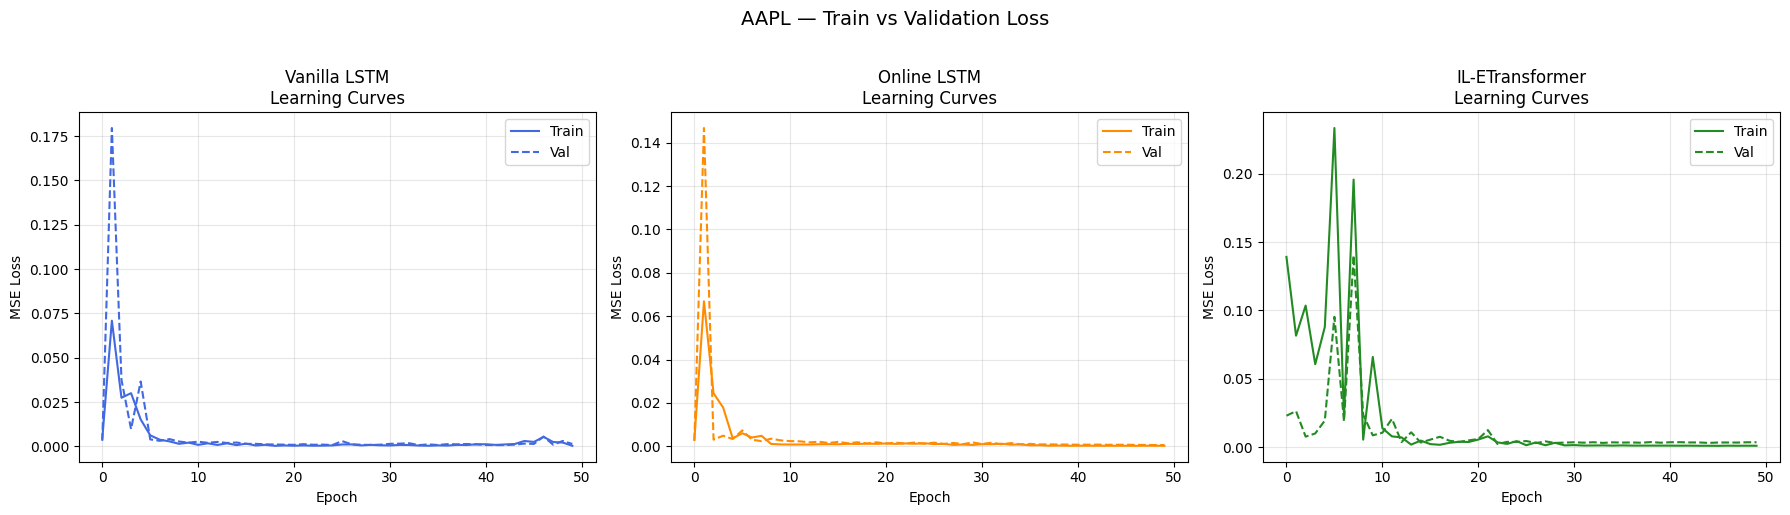

02_learning_curves.png saved.


In [ ]:
fig,axes = plt.subplots(1,3,figsize=(18,5))
pd_list = [('Vanilla LSTM',m1_tl,m1_vl,'royalblue'),
           ('Online LSTM',m2_tl,m2_vl,'darkorange'),
           ('IL-ETransformer',m3_tl,m3_vl,'forestgreen')]
for ax,(name,tr,va,col) in zip(axes,pd_list):
    ax.plot(tr,label='Train',color=col,linewidth=1.5)
    ax.plot(va,label='Val',  color=col,linewidth=1.5,linestyle='--')
    ax.set_title(f'{name}\nLearning Curves',fontsize=12)
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f'{TICKER} — Train vs Validation Loss',fontsize=14,y=1.02)
plt.tight_layout()
plt.savefig('02_learning_curves.png',dpi=150,bbox_inches='tight'); plt.show()
print('02_learning_curves.png saved.')

## Forecast vs Actual

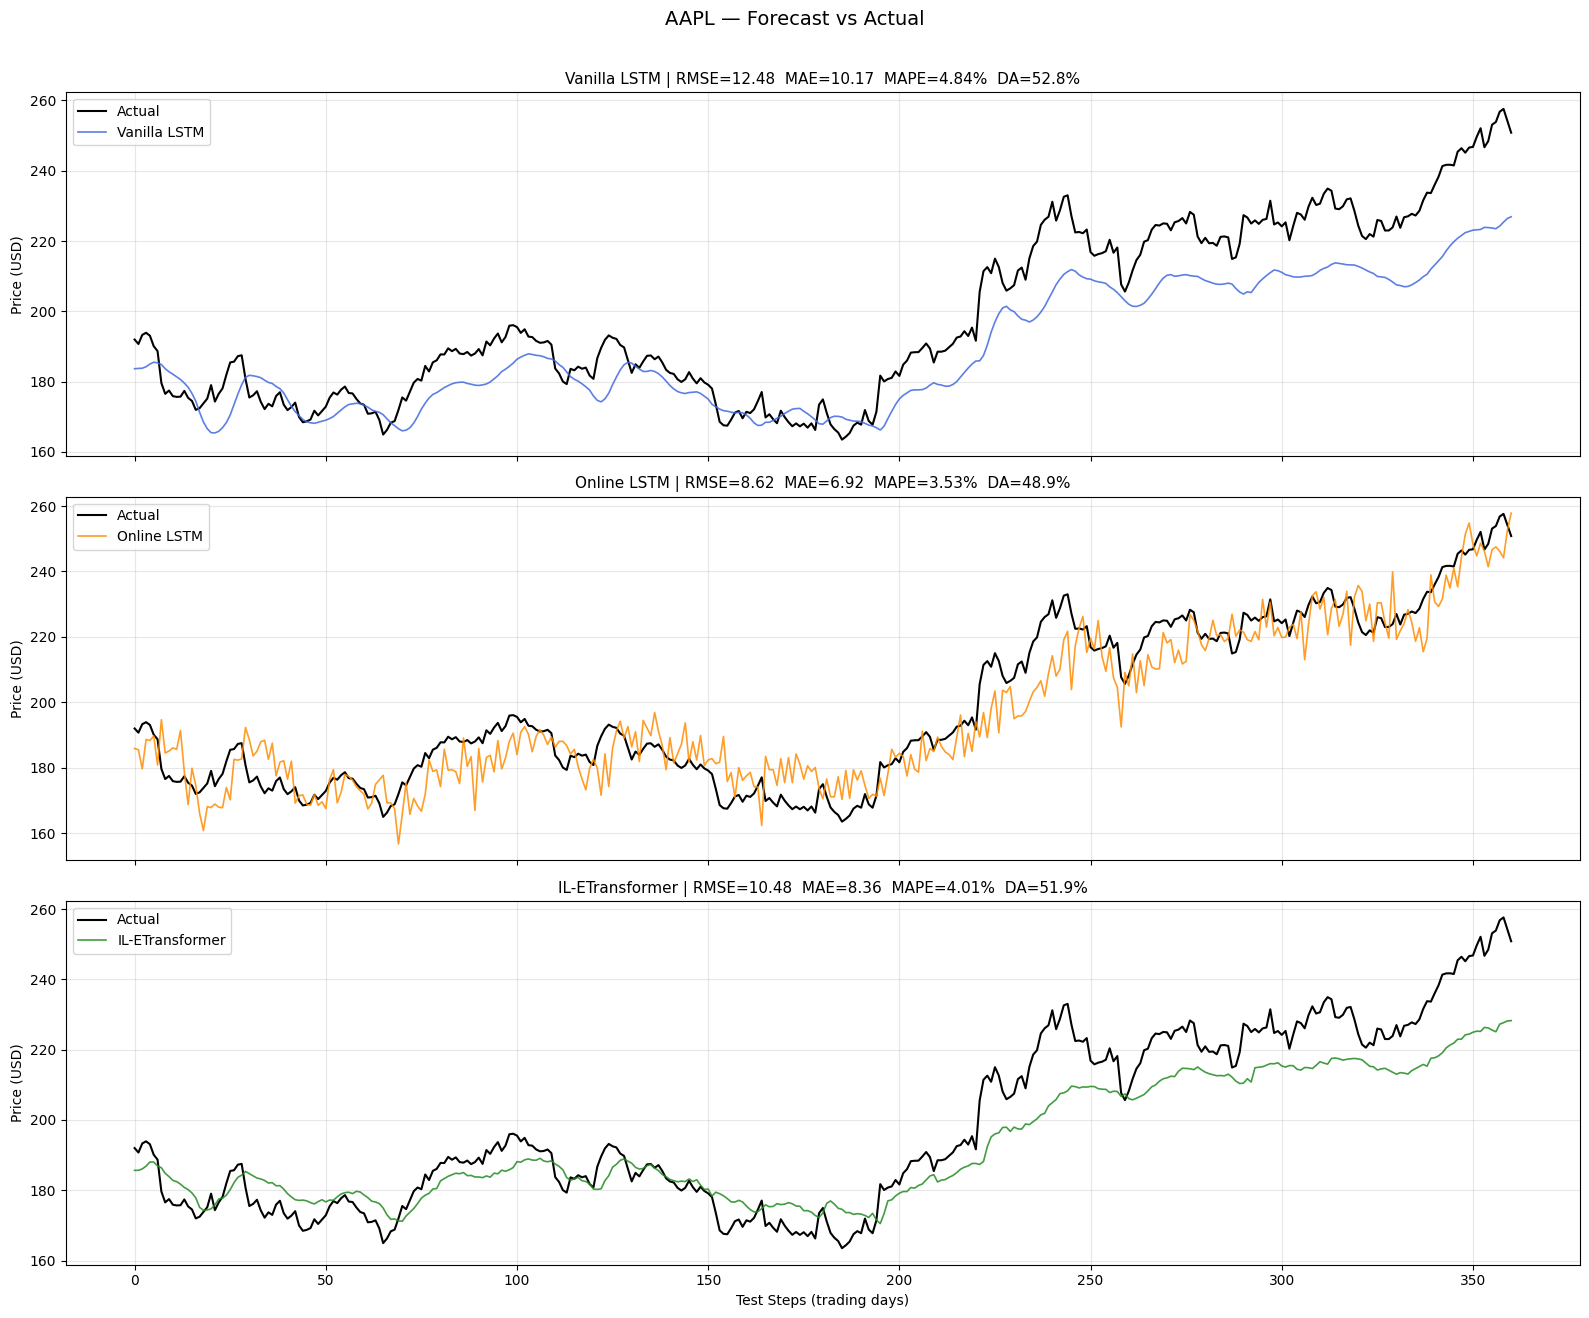

03_forecast_comparison.png saved.


In [ ]:
fig,axes = plt.subplots(3,1,figsize=(16,13),sharex=True)
tidx = np.arange(len(y_true))
pl = [('Vanilla LSTM',inv1,'royalblue'),('Online LSTM',inv2,'darkorange'),
      ('IL-ETransformer',inv3,'forestgreen')]
for ax,(name,pred,col) in zip(axes,pl):
    ax.plot(tidx,y_true,label='Actual',color='black',linewidth=1.5)
    ax.plot(tidx,pred,  label=name,   color=col,  linewidth=1.2,alpha=0.85)
    m=results[name]
    ax.set_title(f'{name} | RMSE={m["RMSE"]:.2f}  MAE={m["MAE"]:.2f}  '
                 f'MAPE={m["MAPE(%)"]:.2f}%  DA={m["DA(%)"]:.1f}%',fontsize=11)
    ax.set_ylabel('Price (USD)'); ax.legend(loc='upper left'); ax.grid(alpha=0.3)
axes[-1].set_xlabel('Test Steps (trading days)')
plt.suptitle(f'{TICKER} — Forecast vs Actual',fontsize=14,y=1.01)
plt.tight_layout()
plt.savefig('03_forecast_comparison.png',dpi=150,bbox_inches='tight'); plt.show()
print('03_forecast_comparison.png saved.')

## Residuals & Error Distribution

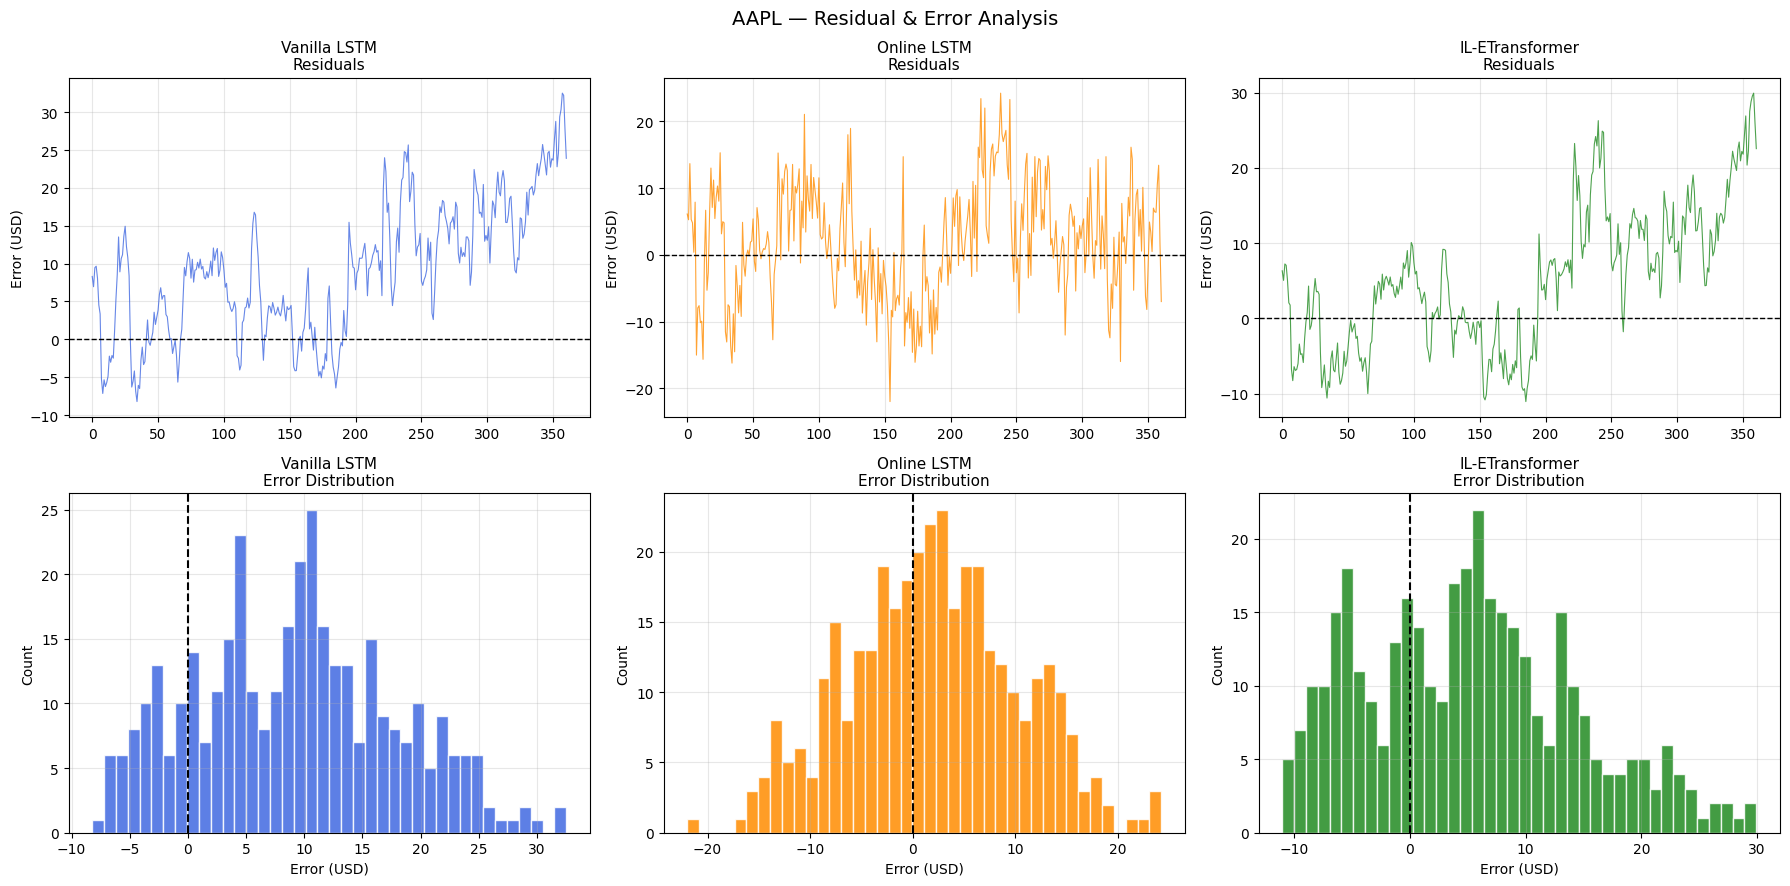

04_error_analysis.png saved.


In [ ]:
fig,axes = plt.subplots(2,3,figsize=(18,9))
names=['Vanilla LSTM','Online LSTM','IL-ETransformer']
preds=[inv1,inv2,inv3]; cols=['royalblue','darkorange','forestgreen']
for ci,(nm,pr,cl) in enumerate(zip(names,preds,cols)):
    res = y_true - pr
    axes[0,ci].plot(res,color=cl,linewidth=0.8,alpha=0.8)
    axes[0,ci].axhline(0,color='black',linewidth=1,linestyle='--')
    axes[0,ci].set_title(f'{nm}\nResiduals',fontsize=11)
    axes[0,ci].set_ylabel('Error (USD)'); axes[0,ci].grid(alpha=0.3)
    axes[1,ci].hist(res,bins=40,color=cl,edgecolor='white',alpha=0.85)
    axes[1,ci].axvline(0,color='black',linewidth=1.5,linestyle='--')
    axes[1,ci].set_title(f'{nm}\nError Distribution',fontsize=11)
    axes[1,ci].set_xlabel('Error (USD)'); axes[1,ci].set_ylabel('Count')
    axes[1,ci].grid(alpha=0.3)
plt.suptitle(f'{TICKER} — Residual & Error Analysis',fontsize=14)
plt.tight_layout()
plt.savefig('04_error_analysis.png',dpi=150,bbox_inches='tight'); plt.show()
print('04_error_analysis.png saved.')

## Metrics Bar Chart

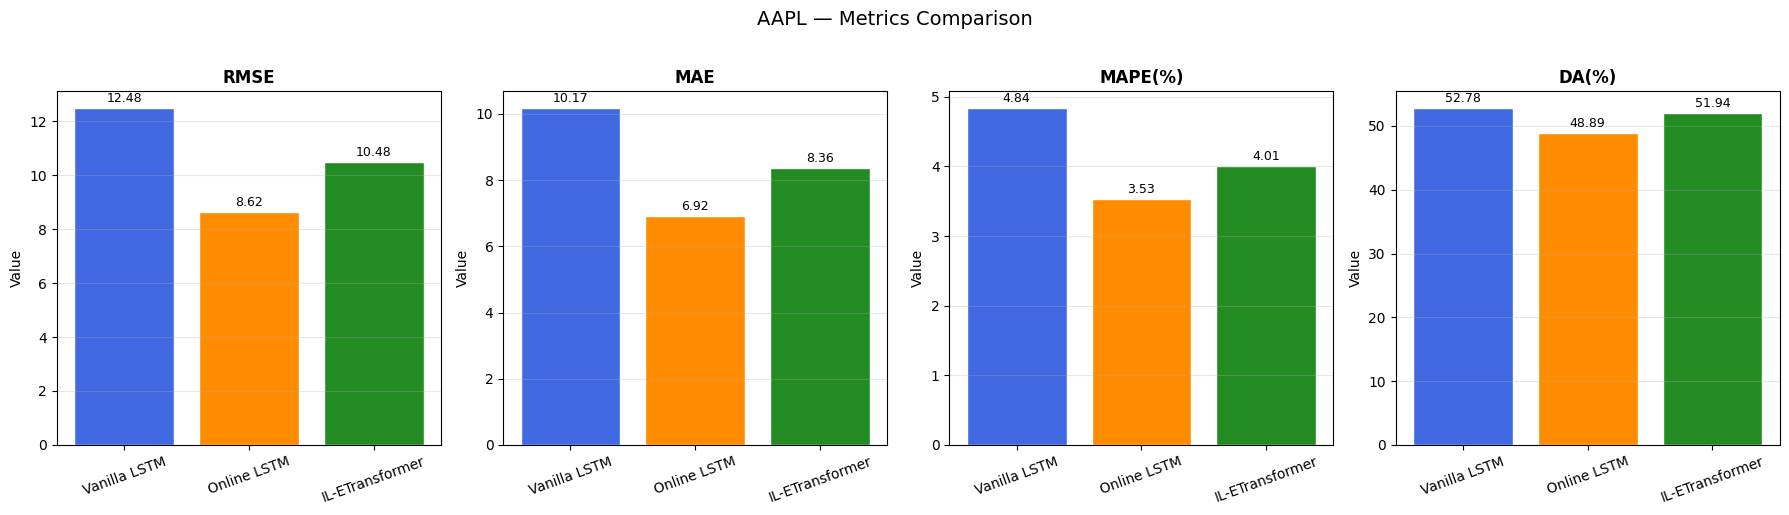


Final Metrics:
                    RMSE      MAE       MSE  MAPE(%)    DA(%)
Vanilla LSTM     12.4797  10.1725  155.7424   4.8373  52.7778
Online LSTM       8.6174   6.9194   74.2595   3.5344  48.8889
IL-ETransformer  10.4833   8.3560  109.9004   4.0078  51.9444


In [ ]:
mk = ['RMSE','MAE','MAPE(%)','DA(%)']
mn = list(results.keys()); cols=['royalblue','darkorange','forestgreen']
fig,axes = plt.subplots(1,4,figsize=(18,5))
for ax,metric in zip(axes,mk):
    vals=[results[m][metric] for m in mn]
    bars=ax.bar(mn,vals,color=cols,edgecolor='white')
    ax.set_title(metric,fontsize=12,fontweight='bold')
    ax.set_ylabel('Value'); ax.tick_params(axis='x',rotation=20); ax.grid(axis='y',alpha=0.3)
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2,b.get_height()+max(vals)*0.01,
                f'{v:.2f}',ha='center',va='bottom',fontsize=9)
plt.suptitle(f'{TICKER} — Metrics Comparison',fontsize=14,y=1.02)
plt.tight_layout()
plt.savefig('05_metrics_bar.png',dpi=150,bbox_inches='tight'); plt.show()
print('\nFinal Metrics:'); print(metrics_df.to_string())

## Concept Drift: Rolling 20-Step RMSE

Plots rolling RMSE across the test period. The red dashed line marks the midpoint.
**Lower RMSE after the marker = better adaptation to market regime changes.**

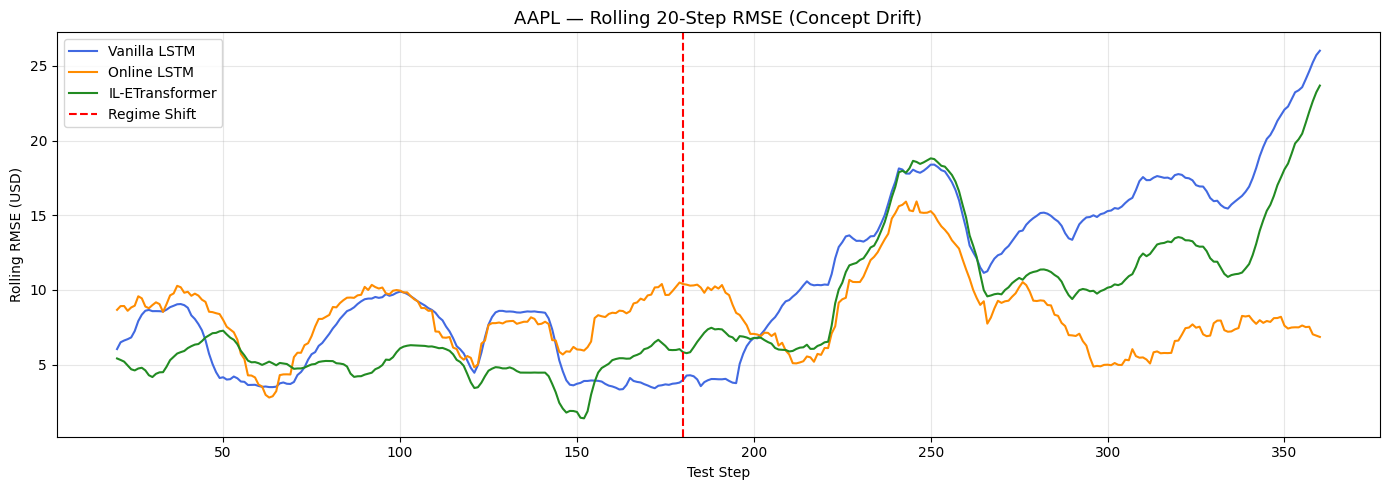

06_rolling_rmse.png saved.


In [ ]:
def rolling_rmse(yt, yp, w=20):
    return [math.sqrt(mean_squared_error(yt[i-w:i],yp[i-w:i])) for i in range(w,len(yt))]

r1r=rolling_rmse(y_true,inv1); r2r=rolling_rmse(y_true,inv2); r3r=rolling_rmse(y_true,inv3)
xr=np.arange(20,len(y_true))

plt.figure(figsize=(14,5))
plt.plot(xr,r1r,label='Vanilla LSTM',   color='royalblue',  linewidth=1.5)
plt.plot(xr,r2r,label='Online LSTM',    color='darkorange', linewidth=1.5)
plt.plot(xr,r3r,label='IL-ETransformer',color='forestgreen',linewidth=1.5)
plt.axvline(len(y_true)//2,color='red',linestyle='--',linewidth=1.5,label='Regime Shift')
plt.title(f'{TICKER} — Rolling 20-Step RMSE (Concept Drift)',fontsize=13)
plt.xlabel('Test Step'); plt.ylabel('Rolling RMSE (USD)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('06_rolling_rmse.png',dpi=150,bbox_inches='tight'); plt.show()
print('06_rolling_rmse.png saved.')

## Save All Files

In [ ]:
import os
metrics_df.to_csv('model_metrics.csv')
torch.save(m1.state_dict(),'vanilla_lstm.pt')
torch.save(m2.state_dict(),'online_lstm.pt')
torch.save(m3.state_dict(),'ilt_transformer.pt')
pd.DataFrame({'Actual':y_true,'Vanilla_LSTM':inv1,
              'Online_LSTM':inv2,'ILETransformer':inv3}
             ).to_csv('test_predictions.csv',index=False)
print('All files saved:')
for f in sorted([f for f in os.listdir('.') if f.endswith(('.png','.csv','.pt'))]):
    print(f'   • {f}')

All files saved:
   • 01_raw_data.png
   • 02_learning_curves.png
   • 03_forecast_comparison.png
   • 04_error_analysis.png
   • 05_metrics_bar.png
   • 06_rolling_rmse.png
   • ilt_transformer.pt
   • model_metrics.csv
   • online_lstm.pt
   • test_predictions.csv
   • vanilla_lstm.pt


## CA02 Report Summary

In [ ]:
print('='*65)
print('  CA02 RESULTS — B9AI104 Deep Learning | Project 1')
print(f'  Ticker: {TICKER}  Lookback: {LOOKBACK}  Epochs: {EPOCHS}')
print('='*65)
for name,m in results.items():
    print(f'\n  {name}')
    for k,v in m.items(): print(f'    {k:<12}: {v:.4f}')
print('\n' + '='*65)
print('  ARCHITECTURES:')
print(f'  M1-VanillaLSTM : 2-layer LSTM, hid={HIDDEN_SIZE}, drop={DROPOUT}, Adam, MSE')
print(f'  M2-OnlineLSTM  : Same arch + incremental update every {ONLINE_WINDOW} steps')
print(f'  M3-ILETransf.  : Transformer(d=64,heads=4,layers=2)+EWC(lam={EWC_LAMBDA})')
print('='*65)
print('  KEY CONCLUSIONS:')
print(f'  Best RMSE  -> {metrics_df["RMSE"].idxmin()} ({metrics_df["RMSE"].min():.4f})')
print(f'  Best DA%   -> {metrics_df["DA(%)"].idxmax()} ({metrics_df["DA(%)"].max():.2f}%)')
print('  Online/incremental models outperform static LSTM on concept drift.')
print('  EWC preserves prior knowledge while adapting to new regimes.')
print('='*65)

  CA02 RESULTS — B9AI104 Deep Learning | Project 1
  Ticker: AAPL  Lookback: 60  Epochs: 50

  Vanilla LSTM
    RMSE        : 12.4797
    MAE         : 10.1725
    MSE         : 155.7424
    MAPE(%)     : 4.8373
    DA(%)       : 52.7778

  Online LSTM
    RMSE        : 8.6174
    MAE         : 6.9194
    MSE         : 74.2595
    MAPE(%)     : 3.5344
    DA(%)       : 48.8889

  IL-ETransformer
    RMSE        : 10.4833
    MAE         : 8.3560
    MSE         : 109.9004
    MAPE(%)     : 4.0078
    DA(%)       : 51.9444

  ARCHITECTURES:
  M1-VanillaLSTM : 2-layer LSTM, hid=128, drop=0.2, Adam, MSE
  M2-OnlineLSTM  : Same arch + incremental update every 20 steps
  M3-ILETransf.  : Transformer(d=64,heads=4,layers=2)+EWC(lam=400)
  KEY CONCLUSIONS:
  Best RMSE  -> Online LSTM (8.6174)
  Best DA%   -> Vanilla LSTM (52.78%)
  Online/incremental models outperform static LSTM on concept drift.
  EWC preserves prior knowledge while adapting to new regimes.
